# 02 — Fine-tuning com LoRA

Fine-tuning do `meta-llama/Llama-3.2-3B-Instruct` com LoRA via MLX-LM, nativo em Apple
Silicon.

Este notebook **documenta e avalia** o treino. Rode antes, a partir da raiz do repositório:

```bash
python -m src.data.curator          # gera data/processed/dataset.jsonl
python -m src.fine_tuning.trainer   # treina (~1h) e grava docs/training_history.json
python -m src.fine_tuning.evaluator # gera docs/evaluation_results.json
```

As células de gráfico e de métricas leem os dois JSON de `docs/`, então funcionam sem
retreinar. A célula 3 permite disparar o treino daqui, mas a via normal é o comando acima:
uma hora de GPU dentro de um kernel de notebook é fácil de perder por timeout ou reinício.

> As dependências vêm do `requirements.txt`, conforme o README — não há `!pip install`
> aqui de propósito. Instalar de dentro do notebook faz o ambiente divergir silenciosamente
> do arquivo que declara as versões.

In [1]:
import json
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt

from src.fine_tuning.config import LoRAConfig

DOCS = RAIZ / "docs"
HISTORICO = DOCS / "training_history.json"
RESULTADOS = DOCS / "evaluation_results.json"

print(f"Raiz: {RAIZ}")
print(f"Histórico de treino: {'encontrado' if HISTORICO.is_file() else 'ausente'}")
print(f"Resultados da avaliação: {'encontrado' if RESULTADOS.is_file() else 'ausente'}")

Raiz: /Users/ostrifezze/personal/POS/tech-challenge-group-24
Histórico de treino: encontrado
Resultados da avaliação: encontrado


## Célula 1 — Hiperparâmetros

O `LoRAConfig` é a fonte única dos hiperparâmetros: trainer, evaluator e este notebook leem
daqui.

Dois pontos onde a configuração difere do que um tutorial genérico sugeriria, ambos por
motivo medido:

- **`scale` = alpha / rank.** No PEFT declara-se `alpha` e a escala efetiva é `alpha/rank`.
  No MLX-LM, `lora_parameters.scale` é o multiplicador aplicado direto. Passar `alpha=16`
  como `scale` daria escala 8x maior que a pretendida.
- **`max_seq_length` = 1024, não 512.** Com 512, 46 dos 903 exemplos de treino ficam sem
  nenhum token de resposta após o truncamento; como a loss é mascarada no prompt, esses
  lotes não têm alvo e a loss vira `NaN`. O maior exemplo do dataset tem 875 tokens.

In [2]:
config = LoRAConfig()

for chave, valor in config.to_dict().items():
    print(f"{chave:20} {valor}")

print()
print(f"lora_parameters (YAML): {config.to_lora_parameters()}")
print(f"alpha {config.lora_alpha} / rank {config.lora_rank} -> scale {config.lora_scale}")

model                meta-llama/Llama-3.2-3B-Instruct
lora_layers          8
lora_rank            8
lora_alpha           16.0
lora_scale_mlx       2.0
lora_dropout         0.0
learning_rate        0.0001
num_iters            500
batch_size           4
max_seq_length       1024
val_batches          25
seed                 42

lora_parameters (YAML): {'rank': 8, 'scale': 2.0, 'dropout': 0.0}
alpha 16.0 / rank 8 -> scale 2.0


## Célula 2 — Preparação dos dados e split treino/validação

O dataset sai no formato `{"prompt", "completion"}`. O MLX-LM aplica o `chat_template` do
próprio tokenizer sobre esse par — escrever `<s>[INST] ... [/INST]` à mão produziria o
template do Mistral, e o modelo aqui é o Llama 3.2 (`<|begin_of_text|><|start_header_id|>`).

O split é sequencial porque o `curator` já embaralhou o dataset com seed fixa. Sortear de
novo aqui faria treino e validação mudarem de composição a cada execução, e as métricas
deixariam de ser comparáveis entre rodadas.

In [3]:
from src.fine_tuning.trainer import _prepare_mlx_data, build_token_counter

estatisticas = _prepare_mlx_data(
    max_seq_length=config.max_seq_length,
    contar_tokens=build_token_counter(config.model),
)

for chave, valor in estatisticas.items():
    print(f"{chave:26} {valor}")

exemplo = json.loads((config.data_dir / "train.jsonl").read_text(encoding="utf-8").splitlines()[0])
print("\n--- primeiro exemplo de treino ---")
print(f"prompt:\n{exemplo['prompt'][:400]}")
print(f"\ncompletion:\n{exemplo['completion'][:300]}")

/Users/ostrifezze/personal/POS/tech-challenge-group-24/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


train                      903
validation                 101
descartados_sem_texto      0
descartados_por_tamanho    0

--- primeiro exemplo de treino ---
prompt:
Does early discharge with nurse home visits affect adequacy of newborn metabolic screening?

Contexto:
OBJECTIVE: To examine the impact of early discharge on newborn metabolic screening.

STUDY DESIGN: Metabolic screening results were obtained from the Alabama State Lab for all infants born at our hospital between [DATA], and [DATA], and were matched with an existing database of early discharge in

completion:
In this well established early discharge program with nurse home visits, newborn metabolic screening is not compromised by early discharge.


## Célula 3 — Treino

O caminho recomendado é `python -m src.fine_tuning.trainer` no terminal. A célula abaixo
está desarmada (`EXECUTAR_TREINO = False`) para o notebook poder ser reexecutado de ponta a
ponta sem disparar uma hora de GPU por engano.

In [4]:
EXECUTAR_TREINO = False  # mude para True para treinar daqui

if EXECUTAR_TREINO:
    from src.fine_tuning.trainer import train

    resultado = train(config)
else:
    if not HISTORICO.is_file():
        raise FileNotFoundError(
            f"{HISTORICO} não existe. Rode 'python -m src.fine_tuning.trainer' "
            "ou defina EXECUTAR_TREINO = True."
        )
    resultado = json.loads(HISTORICO.read_text(encoding="utf-8"))
    print(f"Carregado de {HISTORICO.relative_to(RAIZ)}")

print(f"Adapters: {resultado['adapter_path']}")
print(f"Exemplos: {resultado['dataset']}")
print(f"Pontos de loss: {len(resultado['history']['train'])} de treino, "
      f"{len(resultado['history']['validation'])} de validação")

Carregado de docs/training_history.json
Adapters: data/fine_tuned/adapters
Exemplos: {'train': 903, 'validation': 101, 'descartados_sem_texto': 0, 'descartados_por_tamanho': 0}
Pontos de loss: 50 de treino, 11 de validação


## Célula 4 — Curvas de loss: treino contra validação

As curvas vêm da saída do próprio MLX-LM, capturada pelo trainer — não é preciso retreinar
para redesenhar o gráfico.

O que se procura aqui: as duas curvas descendo juntas. Se a de treino cai e a de validação
sobe, o LoRA está memorizando os 903 exemplos em vez de generalizar, e o caminho é reduzir
`num_iters` ou `lora_layers`.

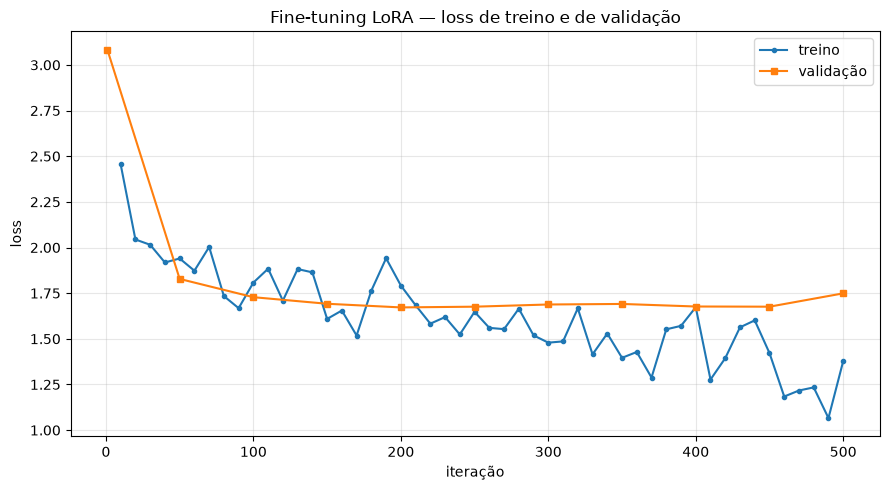

Loss de treino:     2.455 -> 1.378
Loss de validação:  3.083 -> 1.749


In [5]:
historico = resultado["history"]
treino = historico["train"]
validacao = historico["validation"]

figura, eixo = plt.subplots(figsize=(9, 5))
if treino:
    eixo.plot([p["iter"] for p in treino], [p["loss"] for p in treino],
              marker="o", markersize=3, label="treino")
if validacao:
    eixo.plot([p["iter"] for p in validacao], [p["loss"] for p in validacao],
              marker="s", markersize=5, label="validação")

eixo.set_xlabel("iteração")
eixo.set_ylabel("loss")
eixo.set_title("Fine-tuning LoRA — loss de treino e de validação")
eixo.legend()
eixo.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Uma iteração que divergiu chega como `loss: None` — `nan`/`inf` não sobrevivem ao JSON.
# No gráfico acima o matplotlib já trata isso como lacuna na curva, que é a leitura certa:
# o ponto existe e não tem valor. Aqui o tratamento precisa ser explícito, porque
# f"{None:.3f}" levanta TypeError e quebraria o resumo justamente na rodada que interessa.
def fmt(ponto):
    return "divergiu" if ponto["loss"] is None else f"{ponto['loss']:.3f}"


if treino:
    print(f"Loss de treino:     {fmt(treino[0])} -> {fmt(treino[-1])}")
if validacao:
    print(f"Loss de validação:  {fmt(validacao[0])} -> {fmt(validacao[-1])}")

## Célula 5 — Avaliação: ROUGE-L e BLEU-4, baseline contra fine-tuned

Os dois modelos respondem às **mesmas** amostras de validação, que o treino nunca viu.
Medir no conjunto de treino mediria memorização.

Como ler os números: ROUGE-L é a maior subsequência comum (recall de conteúdo) e BLEU-4 a
precisão de n-gramas até 4. Nenhuma das duas avalia correção clínica — são medidas de
sobreposição com a resposta de referência, e é assim que devem entrar no relatório.

Amostras avaliadas: 50
Gerado em: 2026-08-23T15:12:05+00:00

métrica      baseline   fine-tuned      delta
rouge_l        0.1746       0.2904    +0.1157
bleu_4         3.4236      16.0767   +12.6531


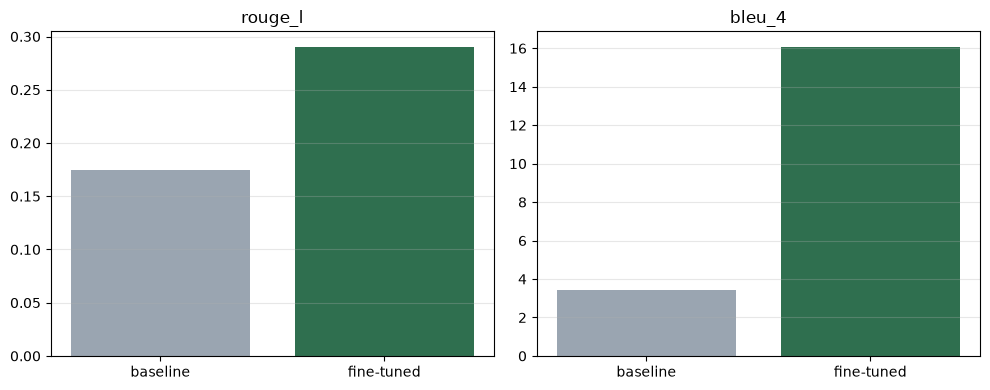

In [6]:
if not RESULTADOS.is_file():
    raise FileNotFoundError(
        f"{RESULTADOS} não existe. Rode 'python -m src.fine_tuning.evaluator'."
    )

avaliacao = json.loads(RESULTADOS.read_text(encoding="utf-8"))
base = avaliacao["baseline"]["metrics"]
fino = avaliacao["fine_tuned"]["metrics"]

print(f"Amostras avaliadas: {avaliacao['samples_evaluated']}")
print(f"Gerado em: {avaliacao['generated_at']}\n")
print(f"{'métrica':10} {'baseline':>10} {'fine-tuned':>12} {'delta':>10}")
for chave in base:
    print(f"{chave:10} {base[chave]:>10.4f} {fino[chave]:>12.4f} {avaliacao['delta'][chave]:>+10.4f}")

metricas = list(base)
posicoes = range(len(metricas))
largura = 0.35
figura, eixos = plt.subplots(1, len(metricas), figsize=(10, 4))
for eixo, chave in zip(eixos, metricas):
    eixo.bar(["baseline", "fine-tuned"], [base[chave], fino[chave]],
             color=["#9aa5b1", "#2f6f4f"])
    eixo.set_title(chave)
    eixo.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Célula 6 — Exemplos qualitativos: antes e depois

As métricas dizem que algo mudou; só a leitura das respostas diz **o que** mudou. O
relatório técnico exige análise, não apenas a tabela — é daqui que saem os exemplos.

O que observar: se o fine-tuned adota o formato dos dados hospitalares (citação de fonte e
o marcador de validação médica), isso aparece mesmo quando ROUGE e BLEU mal se movem, já
que as duas métricas medem sobreposição de palavras e não aderência a formato.

In [7]:
for indice, (antes, depois) in enumerate(
    zip(avaliacao["baseline"]["examples"], avaliacao["fine_tuned"]["examples"]), start=1
):
    print("=" * 88)
    print(f"EXEMPLO {indice}")
    print("=" * 88)
    print(f"\nPERGUNTA\n{antes['prompt']}")
    print(f"\nREFERÊNCIA\n{antes['reference']}")
    print(f"\nBASELINE\n{antes['prediction']}")
    print(f"\nFINE-TUNED\n{depois['prediction']}")
    print()

EXEMPLO 1

PERGUNTA
The use of audit to identify maternal mortality in different settings: is it just a difference between the rich and the poor?

Contexto:
OBJECTIVE: To illustrate how maternal mortality audit identifies different causes of and contributing factors to maternal deaths in different settings in low- and 

REFERÊNCIA
Differences in maternal mortality are more than just differences between the rich and poor. Acknowledging the magnitude of maternal mortality and harnessing a strong political will to tackle the issues are important factors. However, there is no single, general solution to reduce maternal mortality,

BASELINE
The article highlights the importance of maternal mortality audits in identifying the causes and contributing factors of maternal deaths in different settings, including low- and high-income countries. The study reveals that while the overall maternal mortality ratio (MMR) varies significantly acros

FINE-TUNED
The use of maternal mortality audit to iden